# Section 4.2

## Example 4.2.1

In [ ]:
using Polynomials
p = Polynomial([3.5, -4, 1])
r = roots(p)
rmin, rmax = extrema(r)
@show rmin, rmax;

$$
\begin{gather*}
g(x) := x - p(x) \\[1ex]
p(r) = 0 \implies g(r) = r
\end{gather*}
$$

In [ ]:
g(x) = x - p(x);

In [ ]:
using Plots, LaTeXStrings
theme(:dark); default(thickness_scaling=1.5)
plt = plot([g x->x], 2, 3;
    l=2, label=[L"y=g(x)" L"y=x"], xlabel=L"x",  ylabel=L"y", aspect_ratio=1, legend=:bottomright)

In [ ]:
x = 2.1;
y = g(x)

In [ ]:
plot!([x, y], [y, y], arrow=true, label="", color=3)

In [ ]:
x = y;  y = g(x)
plot!([x, x], [x, y], arrow=true, label="", color=4)

In [ ]:
for k = 1:5
    plot!([x, y], [y, y], color=3, label="");  
    x = y                               # y becomes the new x
    y = g(x)                            # g(x) becomes the new y
    plot!([x, x], [x, y], color=4, label="")  
end
plt

In [ ]:
abs(y - rmax) / rmax

In [ ]:
plt = plot([g x->x], 1, 2, l=2, label=[L"y=g(x)" L"y=x"], aspect_ratio=1, 
    xlabel=L"x", ylabel=L"y", legend=:bottomright)

x = 1.297; y = g(x);
arrow = false
for k = 1:5
    plot!([x, y], [y, y], arrow=arrow, label="", color=3)  
    x = y       # y --> new x
    y = g(x)    # g(x) --> new y
    plot!([x, x], [x, y], arrow=arrow, label="", color=4)
    if k > 2; arrow = true; end
end
plt

## Example 4.2.3

In [1]:
using Polynomials
p = Polynomial([3.5, -4, 1])
r = roots(p)
rmin, rmax = extrema(r)

(1.2928932188134525, 2.7071067811865475)

In [2]:
g(x) = x - p(x)
x = [2.1]
for k = 1:12
    push!(x, g(x[k]))
end
x

13-element Vector{Float64}:
 2.1
 2.59
 2.7419000000000002
 2.69148439
 2.713333728386328
 2.7044887203327885
 2.7081843632566587
 2.7066592708954196
 2.7072919457529734
 2.7070300492259465
 2.707138558717502
 2.707093617492436
 2.7071122335938966

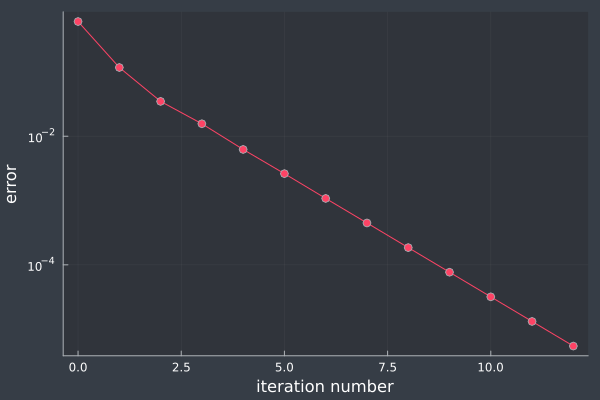

In [3]:
using Plots
theme(:dark)
ε = @. x - rmax
plot(0:12, abs.(ε); label="",
    m=:o, xaxis=("iteration number"),  yaxis=("error", :log10))

$$
\begin{align*}
\log |\epsilon_k| &\approx m k + b \\[1ex]
|\epsilon_k| &\approx e^b \cdot e^{m k} = C \sigma^k, \quad \sigma = e^m
\end{align*}
$$

In [4]:
y = @. log(abs(ε[5:12]))
p = Polynomials.fit(5:12, y, 1)

Polynomial(-0.6680573888302033 - 0.8807181589734457*x)

In [5]:
σ = exp(p.coeffs[2])

0.4144851385485472

In [6]:
[abs(ε[i+1] / ε[i]) for i in 8:11]

4-element Vector{Float64}:
 0.4137660520817109
 0.4143987269383
 0.4141368304124451
 0.4142453399049934